<a href="https://colab.research.google.com/github/Wuanzz/FER-Video-Emotion-Recognition/blob/main/model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — Kết nối Google Drive & Khởi tạo Cấu hình Đường dẫn

In [1]:
from google.colab import drive

drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video'

DATASET_ZIP = os.path.join(PROJECT_DIR, 'ravdess.zip')

PROCESSED_DIR = os.path.join(PROJECT_DIR, 'processed_data')

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("ZIP:", DATASET_ZIP)
print("Tồn tại:", os.path.exists(DATASET_ZIP))

if os.path.exists(DATASET_ZIP):
    print("Dung lượng ZIP:",
          round(os.path.getsize(DATASET_ZIP) / (1024**3), 2),
          "GB")

Mounted at /content/drive
ZIP: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/ravdess.zip
Tồn tại: True
Dung lượng ZIP: 23.86 GB




# Cell 2 — Kiểm tra & Khám phá Cấu trúc Dữ liệu Batch



In [2]:
import numpy as np
import os

BATCH_DIR = os.path.join(PROCESSED_DIR, 'ravdess_batches')

batch_files = sorted([
    f for f in os.listdir(BATCH_DIR)
    if f.endswith('.npz')
])

print("Số batch:", len(batch_files))
print("Batch đầu tiên:", batch_files[0])

sample_batch_path = os.path.join(BATCH_DIR, batch_files[0])

data = np.load(sample_batch_path)

print("\nCác key trong batch:")
print(data.files)

for key in data.files:
    print(f"\n{key}:")
    print("Shape:", data[key].shape)
    print("Dtype:", data[key].dtype)

Số batch: 29
Batch đầu tiên: batch_001.npz

Các key trong batch:
['X', 'y']

X:
Shape: (100, 16, 224, 224, 3)
Dtype: uint8

y:
Shape: (100,)
Dtype: int64


#Cell 3 — Khởi tạo Cấu hình Nhãn Cảm *xúc*

In [3]:
IMAGE_SIZE = (224, 224)

SEQUENCE_LENGTH = 16

EMOTION_MAP = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

print("IMAGE_SIZE:", IMAGE_SIZE)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("Số emotion:", len(EMOTION_MAP))

IMAGE_SIZE: (224, 224)
SEQUENCE_LENGTH: 16
Số emotion: 8


#Cell 4 — Load Model Checkpoint & Configuration

In [4]:
# Cell 4 — Load Best Model Checkpoint

import torch
import os

MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

checkpoint = torch.load(MODEL_PATH, map_location='cpu')

MODEL_CONFIG = checkpoint['config']

print("Best model loaded successfully.")
print("Best epoch:", checkpoint['epoch'])
print("Best validation accuracy:",
      f"{checkpoint['val_acc'] * 100:.2f}%")

print("\nModel configuration:")
for key, value in MODEL_CONFIG.items():
    print(f"  {key}: {value}")

Best model loaded successfully.
Best epoch: 13
Best validation accuracy: 81.58%

Model configuration:
  image_size: (224, 224)
  sequence_length: 16
  num_classes: 8
  backbone: resnet18
  rnn_type: LSTM
  hidden_dim: 256
  num_rnn_layers: 2
  dropout: 0.5
  batch_size: 16
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 30
  seed: 42


#Cell 5 — Xây dựng đúng kiến trúc model

In [5]:
#Build Spatial-Temporal FER Model

import torch.nn as nn
from torchvision import models

class SpatialTemporalFERModel(nn.Module):
    def __init__(
        self,
        backbone_name='resnet18',
        rnn_type='LSTM',
        hidden_dim=256,
        num_rnn_layers=2,
        dropout=0.5,
        num_classes=8
    ):
        super().__init__()

        # 1. CNN Backbone
        if backbone_name == 'resnet18':
            resnet = models.resnet18(weights=None)
            feature_dim = resnet.fc.in_features
            resnet.fc = nn.Identity()
            self.backbone = resnet

        elif backbone_name == 'mobilenet_v2':
            mobilenet = models.mobilenet_v2(weights=None)
            feature_dim = mobilenet.classifier[1].in_features
            mobilenet.classifier = nn.Identity()
            self.backbone = mobilenet

        else:
            raise ValueError(
                "Backbone không hợp lệ! "
                "Chọn 'resnet18' hoặc 'mobilenet_v2'"
            )

        # 2. RNN
        self.rnn_type = rnn_type

        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=feature_dim,
                hidden_size=hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=True,
                dropout=dropout if num_rnn_layers > 1 else 0
            )

        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=feature_dim,
                hidden_size=hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=True,
                dropout=dropout if num_rnn_layers > 1 else 0
            )

        else:
            raise ValueError(
                "RNN không hợp lệ! Chọn 'LSTM' hoặc 'GRU'"
            )

        # 3. Classifier
        rnn_out_dim = hidden_dim * 2

        self.classifier = nn.Sequential(
            nn.Linear(rnn_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # Input:
        # (B, T, H, W, C) hoặc (B, T, C, H, W)

        if x.dim() == 5 and x.shape[-1] == 3:
            x = x.permute(0, 1, 4, 2, 3)

        batch_size, seq_len, C, H, W = x.shape

        # CNN xử lý từng frame
        x = x.view(batch_size * seq_len, C, H, W)

        cnn_features = self.backbone(x)

        # Ghép lại thành sequence
        rnn_input = cnn_features.view(
            batch_size,
            seq_len,
            -1
        )

        # RNN
        rnn_out, _ = self.rnn(rnn_input)

        # Temporal Global Average Pooling
        out_feature = torch.mean(rnn_out, dim=1)

        # Classification
        logits = self.classifier(out_feature)

        return logits


# Sử dụng cấu hình từ checkpoint
model = SpatialTemporalFERModel(
    backbone_name=MODEL_CONFIG['backbone'],
    rnn_type=MODEL_CONFIG['rnn_type'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    num_rnn_layers=MODEL_CONFIG['num_rnn_layers'],
    dropout=MODEL_CONFIG['dropout'],
    num_classes=MODEL_CONFIG['num_classes']
)

# Load trained weights
model.load_state_dict(checkpoint['model_state_dict'])

# Chuyển model lên GPU nếu có
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

model.eval()

print("Model loaded successfully.")
print("Device:", device)
print("Backbone:", MODEL_CONFIG['backbone'])
print("RNN:", MODEL_CONFIG['rnn_type'])

Model loaded successfully.
Device: cuda
Backbone: resnet18
RNN: LSTM


#Cell 6 — Tái tạo đúng Test Batch Split

In [6]:

import random
import glob

SEED = MODEL_CONFIG['seed']

random.seed(SEED)
np.random.seed(SEED)

batch_files = sorted(
    glob.glob(os.path.join(BATCH_DIR, 'batch_*.npz'))
)

num_batches = len(batch_files)

indices = list(range(num_batches))
np.random.shuffle(indices)

train_split = int(0.70 * num_batches)
val_split = int(0.85 * num_batches)

train_batch_files = [
    batch_files[i] for i in indices[:train_split]
]

val_batch_files = [
    batch_files[i] for i in indices[train_split:val_split]
]

test_batch_files = [
    batch_files[i] for i in indices[val_split:]
]

print("Total batches:", num_batches)
print("Train batches:", len(train_batch_files))
print("Val batches:", len(val_batch_files))
print("Test batches:", len(test_batch_files))

print("\nTest batches:")
for path in test_batch_files:
    print(" -", os.path.basename(path))

Total batches: 29
Train batches: 20
Val batches: 4
Test batches: 5

Test batches:
 - batch_008.npz
 - batch_011.npz
 - batch_015.npz
 - batch_020.npz
 - batch_007.npz


#Cell 7 — Tạo Test Dataset tiết kiệm RAM

In [7]:
# Cell 7 — Xây dựng Test Dataset tối ưu bộ nhớ

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class TestDataset(Dataset):
    def __init__(self, batch_files, transform=None):
        self.batch_files = batch_files
        self.transform = transform

        # Lưu số lượng mẫu của từng batch
        self.batch_sizes = []

        for path in batch_files:
            with np.load(path) as data:
                self.batch_sizes.append(len(data['y']))

        # Tạo danh sách ánh xạ:
        # mỗi index tương ứng với một sample trong một batch
        self.index_map = []

        for batch_idx, size in enumerate(self.batch_sizes):
            for local_idx in range(size):
                self.index_map.append((batch_idx, local_idx))

        # Cache một batch tại một thời điểm để tránh đọc file lặp lại
        self.cached_batch_idx = None
        self.cached_X = None
        self.cached_y = None

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):

        batch_idx, local_idx = self.index_map[idx]

        # Chỉ đọc file khi chuyển sang batch mới
        if batch_idx != self.cached_batch_idx:

            with np.load(self.batch_files[batch_idx]) as data:
                self.cached_X = data['X'].copy()
                self.cached_y = data['y'].copy()

            self.cached_batch_idx = batch_idx

        video_seq = self.cached_X[local_idx]
        label = self.cached_y[local_idx]

        frames = []

        # Tiền xử lý giống quá trình validation/test khi training
        for frame in video_seq:

            frame_tensor = self.transform(frame)

            frames.append(frame_tensor)

        video_tensor = torch.stack(frames, dim=0)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return video_tensor, label_tensor


# Chuẩn hóa giống preprocessing được sử dụng khi training
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_dataset = TestDataset(
    test_batch_files,
    transform=test_transform
)


# Không shuffle để giữ nguyên thứ tự các mẫu Test
test_loader = DataLoader(
    test_dataset,
    batch_size=MODEL_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("Đã tạo Test Dataset.")
print("Số lượng mẫu Test:", len(test_dataset))
print("Số batch Test:", len(test_loader))

Đã tạo Test Dataset.
Số lượng mẫu Test: 500
Số batch Test: 32


# Cell 8 — Đánh giá mô hình tốt nhất trên tập Test

In [8]:
from sklearn.metrics import accuracy_score

model.eval()

all_labels = []
all_predictions = []

# Tắt tính gradient vì đây chỉ là bước đánh giá mô hình
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        # Đưa kết quả từ GPU về CPU để lưu lại
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


# Tính độ chính xác trên toàn bộ tập Test
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("Đánh giá trên tập Test hoàn tất.")
print("Số lượng mẫu đã đánh giá:", len(all_labels))
print(f"Độ chính xác Test (Accuracy): {test_accuracy * 100:.2f}%")

Đánh giá trên tập Test hoàn tất.
Số lượng mẫu đã đánh giá: 500
Độ chính xác Test (Accuracy): 72.60%


#Cell 9 — Tính Precision, Recall và F1-score

In [9]:
from sklearn.metrics import classification_report

# Tên 8 lớp cảm xúc theo thứ tự nhãn của mô hình
CLASS_NAMES = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

# Tạo báo cáo đánh giá chi tiết cho từng cảm xúc
report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST")
print("=" * 60)
print(report)

BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST
              precision    recall  f1-score   support

     neutral     0.8667    0.7222    0.7879        36
        calm     0.8525    0.7222    0.7820        72
       happy     0.8533    0.8889    0.8707        72
         sad     0.6727    0.6607    0.6667        56
       angry     0.4956    1.0000    0.6627        56
     fearful     0.8654    0.7031    0.7759        64
     disgust     0.6437    0.7778    0.7044        72
   surprised     1.0000    0.3750    0.5455        72

    accuracy                         0.7260       500
   macro avg     0.7812    0.7312    0.7245       500
weighted avg     0.7863    0.7260    0.7229       500



#Cell 10 - Confusion Matrix

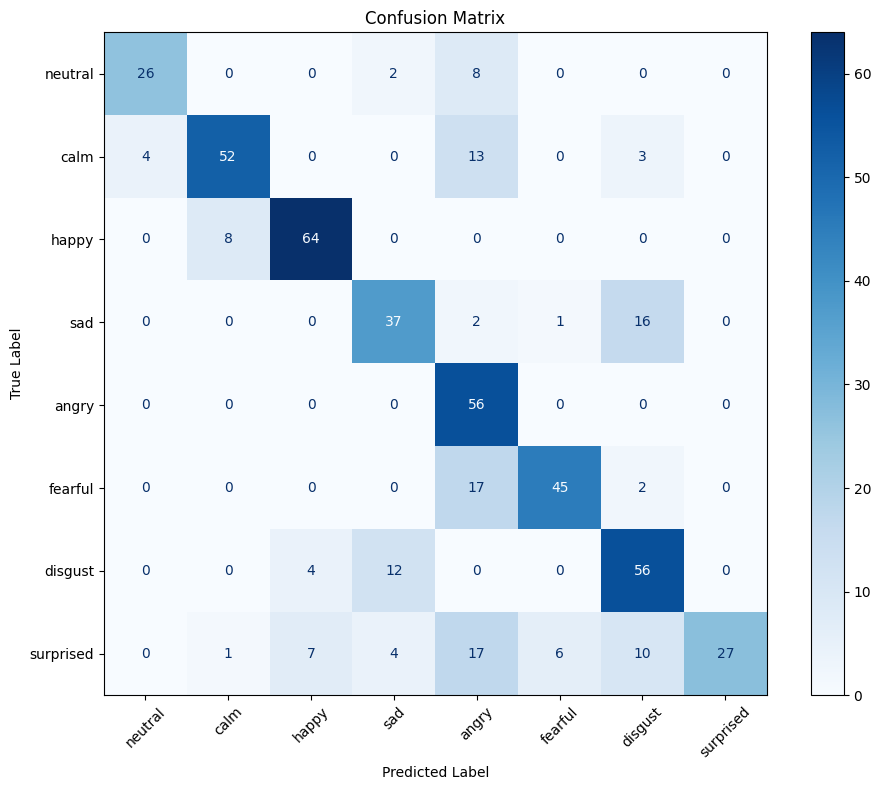

Đã tạo Confusion Matrix.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tính ma trận nhầm lẫn
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(CLASS_NAMES)))
)

# Hiển thị ma trận nhầm lẫn
fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

display.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

# Lưu ma trận nhầm lẫn để sử dụng trong báo cáo
confusion_matrix_path = os.path.join(
    CHECKPOINT_DIR,
    'confusion_matrix.png'
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Đã tạo Confusion Matrix.")
print("Đường dẫn:", confusion_matrix_path)

#Cell 11 - Vẽ Training Loss và Validation Loss

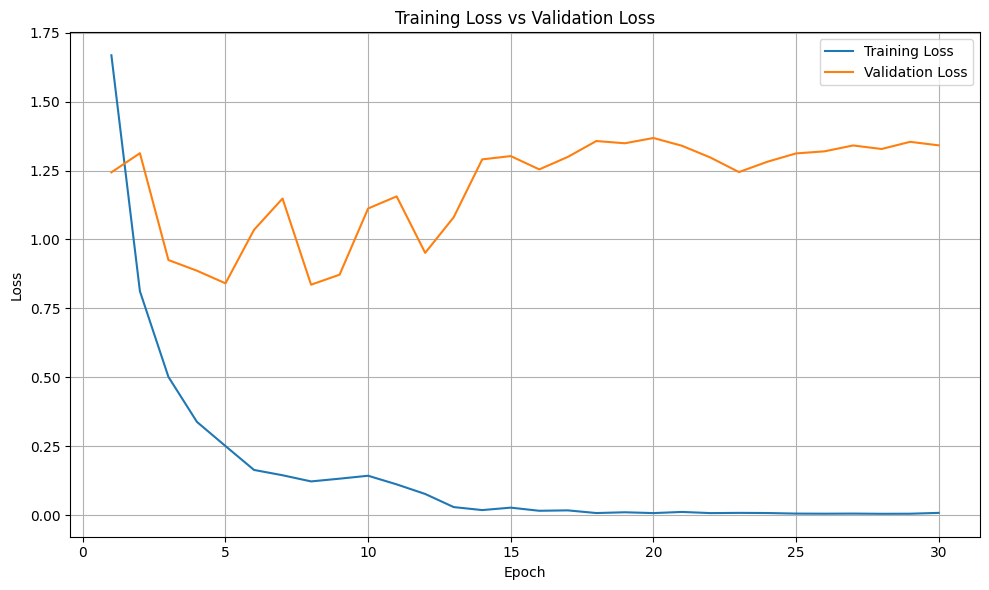

In [11]:
import json
import matplotlib.pyplot as plt

# Đọc lịch sử huấn luyện được lưu từ quá trình training
history_path = os.path.join(
    CHECKPOINT_DIR,
    'training_history.json'
)

with open(history_path, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# Vẽ Training Loss và Validation Loss
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history['train_loss'],
    label='Training Loss'
)

plt.plot(
    epochs,
    history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

#Cell 12 — Vẽ Training Accuracy và Validation Accuracy

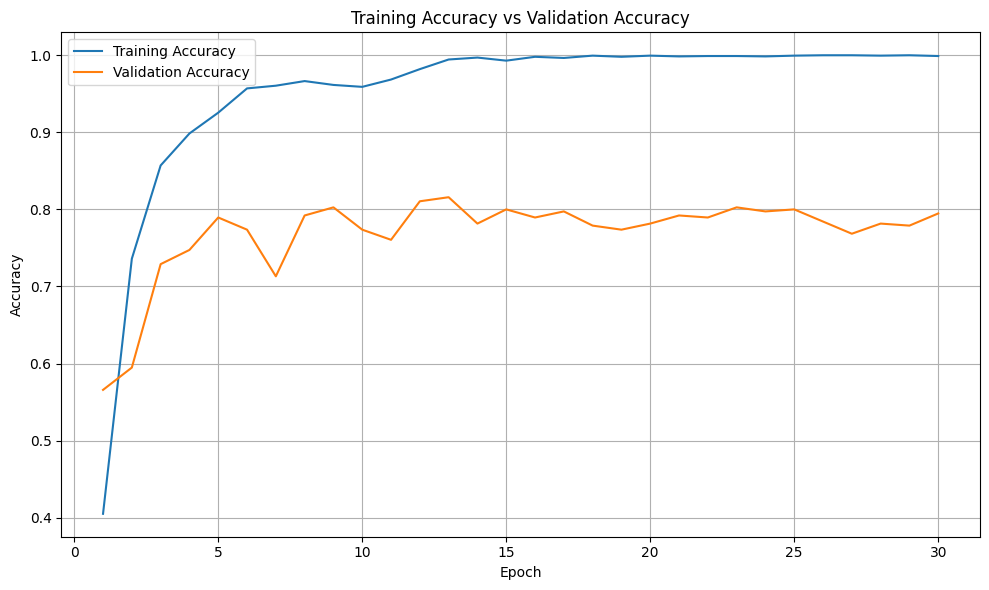

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history['train_acc'],
    label='Training Accuracy'
)

plt.plot(
    epochs,
    history['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

#Cell 13 — Trực quan hóa và Lưu biểu đồ Training Loss, Validation Loss, Training Accuracy và Validation Accuracy

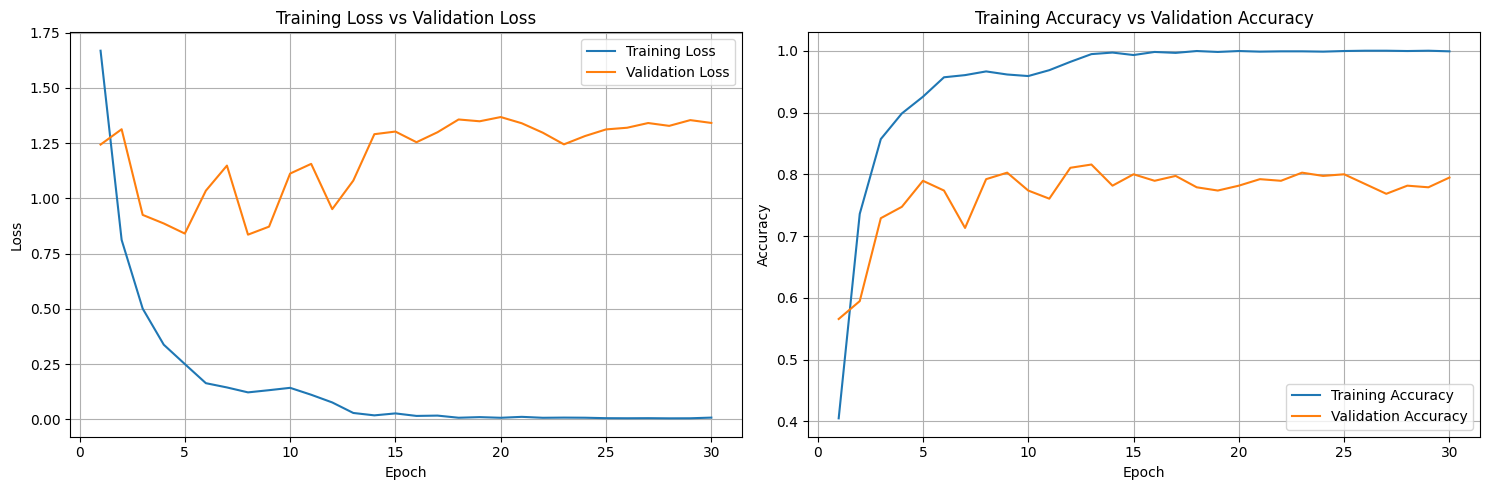

Đã lưu Training Curves.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/training_curves.png


In [13]:
# Cell 13 — Lưu Training Curves

# Tạo figure gồm 2 biểu đồ:
# 1. Training Loss và Validation Loss
# 2. Training Accuracy và Validation Accuracy

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Loss
axes[0].plot(
    epochs,
    history['train_loss'],
    label='Training Loss'
)

axes[0].plot(
    epochs,
    history['val_loss'],
    label='Validation Loss'
)

axes[0].set_title('Training Loss vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)


# Biểu đồ Accuracy
axes[1].plot(
    epochs,
    history['train_acc'],
    label='Training Accuracy'
)

axes[1].plot(
    epochs,
    history['val_acc'],
    label='Validation Accuracy'
)

axes[1].set_title('Training Accuracy vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()

# Lưu hình ảnh để sử dụng trong báo cáo
training_curves_path = os.path.join(
    CHECKPOINT_DIR,
    'training_curves.png'
)

plt.savefig(
    training_curves_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Đã lưu Training Curves.")
print("Đường dẫn:", training_curves_path)

#Cell 14 — Tạo và Lưu Classification Report với Precision, Recall và F1-score theo từng Emotion

Code:

In [14]:
classification_report_path = os.path.join(
    CHECKPOINT_DIR,
    'classification_report.txt'
)

# Lưu báo cáo đánh giá chi tiết vào file TXT
with open(classification_report_path, 'w', encoding='utf-8') as f:
    f.write("CLASSIFICATION REPORT — TEST SET\n")
    f.write("=" * 70 + "\n\n")
    f.write(report)

print("Đã lưu Classification Report.")
print("Đường dẫn:", classification_report_path)

Đã lưu Classification Report.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/classification_report.txt


#Cell 15 — Phân tích và Lưu các Emotion bị Dự đoán Sai Thường Gặp

In [15]:
import pandas as pd
import numpy as np

# Tạo danh sách các cặp Emotion bị dự đoán sai
misclassification_pairs = []

for true_idx in range(len(CLASS_NAMES)):
    for pred_idx in range(len(CLASS_NAMES)):
        # Bỏ qua đường chéo chính vì đây là các dự đoán đúng
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            misclassification_pairs.append({
                'True Emotion': CLASS_NAMES[true_idx],
                'Predicted Emotion': CLASS_NAMES[pred_idx],
                'Number of Errors': int(cm[true_idx, pred_idx])
            })

# Chuyển sang DataFrame và sắp xếp theo số lỗi giảm dần
misclassification_df = pd.DataFrame(
    misclassification_pairs
).sort_values(
    by='Number of Errors',
    ascending=False
).reset_index(drop=True)

print("CÁC CẶP EMOTION BỊ DỰ ĐOÁN NHẦM NHIỀU NHẤT")
print("=" * 70)
print(misclassification_df.to_string(index=False))

# Lưu danh sách lỗi
error_analysis_path = os.path.join(
    CHECKPOINT_DIR,
    'misclassification_pairs.csv'
)

misclassification_df.to_csv(
    error_analysis_path,
    index=False,
    encoding='utf-8-sig'
)

# Hiển thị 5 lỗi phổ biến nhất
print("\n5 CẶP EMOTION BỊ NHẦM NHIỀU NHẤT")
print("-" * 70)

for _, row in misclassification_df.head(5).iterrows():
    print(
        f"- {row['True Emotion']} → {row['Predicted Emotion']}: "
        f"{row['Number of Errors']} mẫu"
    )

# Nhận xét tổng quát
print("\nNHẬN XÉT ERROR ANALYSIS")
print("-" * 70)

print(
    "- Mô hình có xu hướng dự đoán một số Emotion thành 'angry', "
    "đặc biệt là surprised, fearful và calm."
)

print(
    f"- Cặp lỗi lớn nhất là surprised → angry "
    f"với {int(misclassification_df.iloc[0]['Number of Errors'])} mẫu."
)

print(
    "- Emotion disgust cũng có một số trường hợp bị nhầm thành sad, "
    "cho thấy một số biểu cảm có thể có đặc điểm tương đồng."
)

print(
    "- Các lỗi dự đoán có thể liên quan đến sự tương đồng giữa các biểu cảm, "
    "chất lượng frame, góc khuôn mặt hoặc kết quả face detection "
    "trong quá trình preprocessing."
)

print("\nĐã lưu kết quả Error Analysis.")
print("Đường dẫn:", error_analysis_path)

CÁC CẶP EMOTION BỊ DỰ ĐOÁN NHẦM NHIỀU NHẤT
True Emotion Predicted Emotion  Number of Errors
     fearful             angry                17
   surprised             angry                17
         sad           disgust                16
        calm             angry                13
     disgust               sad                12
   surprised           disgust                10
     neutral             angry                 8
       happy              calm                 8
   surprised             happy                 7
   surprised           fearful                 6
        calm           neutral                 4
   surprised               sad                 4
     disgust             happy                 4
        calm           disgust                 3
     neutral               sad                 2
         sad             angry                 2
     fearful           disgust                 2
         sad           fearful                 1
   surprised              

#Cell 16 — Tổng hợp và Lưu Kết quả Đánh giá theo từng Emotion

In [16]:
from sklearn.metrics import classification_report
import pandas as pd

# Tính lại classification report dưới dạng dictionary
report_dict = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

# Tạo bảng kết quả cho từng Emotion
evaluation_rows = []

for emotion in CLASS_NAMES:
    evaluation_rows.append({
        'Emotion': emotion,
        'Precision': report_dict[emotion]['precision'],
        'Recall': report_dict[emotion]['recall'],
        'F1-Score': report_dict[emotion]['f1-score'],
        'Support': int(report_dict[emotion]['support'])
    })

# Thêm các chỉ số tổng hợp
evaluation_rows.append({
    'Emotion': 'Macro Average',
    'Precision': report_dict['macro avg']['precision'],
    'Recall': report_dict['macro avg']['recall'],
    'F1-Score': report_dict['macro avg']['f1-score'],
    'Support': int(report_dict['macro avg']['support'])
})

evaluation_rows.append({
    'Emotion': 'Weighted Average',
    'Precision': report_dict['weighted avg']['precision'],
    'Recall': report_dict['weighted avg']['recall'],
    'F1-Score': report_dict['weighted avg']['f1-score'],
    'Support': int(report_dict['weighted avg']['support'])
})

# Tạo DataFrame
evaluation_df = pd.DataFrame(evaluation_rows)

# Lưu kết quả
evaluation_results_path = os.path.join(
    CHECKPOINT_DIR,
    'evaluation_results.csv'
)

evaluation_df.to_csv(
    evaluation_results_path,
    index=False,
    encoding='utf-8-sig'
)

print("BẢNG KẾT QUẢ ĐÁNH GIÁ")
print("=" * 70)
print(evaluation_df.to_string(index=False))

print("\nĐã lưu Evaluation Results.")
print("Đường dẫn:", evaluation_results_path)

BẢNG KẾT QUẢ ĐÁNH GIÁ
         Emotion  Precision   Recall  F1-Score  Support
         neutral   0.866667 0.722222  0.787879       36
            calm   0.852459 0.722222  0.781955       72
           happy   0.853333 0.888889  0.870748       72
             sad   0.672727 0.660714  0.666667       56
           angry   0.495575 1.000000  0.662722       56
         fearful   0.865385 0.703125  0.775862       64
         disgust   0.643678 0.777778  0.704403       72
       surprised   1.000000 0.375000  0.545455       72
   Macro Average   0.781228 0.731244  0.724461      500
Weighted Average   0.786343 0.726000  0.722898      500

Đã lưu Evaluation Results.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/evaluation_results.csv


#Cell 17 — Tạo Thư mục Lưu Kết quả Error Analysis

In [17]:
ERROR_ANALYSIS_DIR = os.path.join(
    CHECKPOINT_DIR,
    'error_analysis'
)

os.makedirs(
    ERROR_ANALYSIS_DIR,
    exist_ok=True
)

print("Đã tạo thư mục Error Analysis.")
print("Đường dẫn:", ERROR_ANALYSIS_DIR)

Đã tạo thư mục Error Analysis.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/error_analysis


#Cell 18 — Xác định các mẫu Test bị dự đoán sai

In [18]:
# Chuyển kết quả dự đoán sang NumPy array
all_labels_array = np.array(all_labels)
all_predictions_array = np.array(all_predictions)

# Tìm các vị trí mà nhãn thật khác nhãn dự đoán
misclassified_indices = np.where(
    all_labels_array != all_predictions_array
)[0]

print("PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI")
print("=" * 70)

print("Tổng số mẫu Test:", len(all_labels_array))
print("Số mẫu dự đoán sai:", len(misclassified_indices))
print(
    "Tỷ lệ dự đoán sai:",
    f"{len(misclassified_indices) / len(all_labels_array) * 100:.2f}%"
)

print("\n10 mẫu dự đoán sai đầu tiên:")

for idx in misclassified_indices[:10]:
    true_label = CLASS_NAMES[all_labels_array[idx]]
    predicted_label = CLASS_NAMES[all_predictions_array[idx]]

    print(
        f"Index {idx}: "
        f"True = {true_label}, "
        f"Predicted = {predicted_label}"
    )

PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI
Tổng số mẫu Test: 500
Số mẫu dự đoán sai: 137
Tỷ lệ dự đoán sai: 27.40%

10 mẫu dự đoán sai đầu tiên:
Index 0: True = fearful, Predicted = disgust
Index 1: True = fearful, Predicted = angry
Index 2: True = fearful, Predicted = angry
Index 3: True = fearful, Predicted = angry
Index 12: True = surprised, Predicted = angry
Index 13: True = surprised, Predicted = angry
Index 14: True = surprised, Predicted = fearful
Index 15: True = surprised, Predicted = fearful
Index 16: True = surprised, Predicted = angry
Index 17: True = surprised, Predicted = angry


#Cell 19 — Chuẩn bị các mẫu dự đoán sai để kiểm tra trực quan

In [19]:
# Số lượng mẫu sai muốn kiểm tra
NUM_ERROR_SAMPLES = min(12, len(misclassified_indices))

# Lấy các index mẫu sai đầu tiên
selected_error_indices = misclassified_indices[:NUM_ERROR_SAMPLES]

# Tạo danh sách thông tin các mẫu sai
error_samples = []

for idx in selected_error_indices:
    true_label = CLASS_NAMES[all_labels_array[idx]]
    predicted_label = CLASS_NAMES[all_predictions_array[idx]]

    error_samples.append({
        'Test Index': int(idx),
        'True Emotion': true_label,
        'Predicted Emotion': predicted_label
    })

# Chuyển thành DataFrame
error_samples_df = pd.DataFrame(error_samples)

print("CÁC MẪU DỰ ĐOÁN SAI ĐƯỢC CHỌN ĐỂ KIỂM TRA")
print("=" * 70)
print(error_samples_df.to_string(index=False))

# Lưu danh sách các mẫu được chọn
selected_errors_path = os.path.join(
    ERROR_ANALYSIS_DIR,
    'selected_misclassified_samples.csv'
)

error_samples_df.to_csv(
    selected_errors_path,
    index=False,
    encoding='utf-8-sig'
)

print("\nĐã lưu danh sách mẫu dự đoán sai.")
print("Đường dẫn:", selected_errors_path)

CÁC MẪU DỰ ĐOÁN SAI ĐƯỢC CHỌN ĐỂ KIỂM TRA
 Test Index True Emotion Predicted Emotion
          0      fearful           disgust
          1      fearful             angry
          2      fearful             angry
          3      fearful             angry
         12    surprised             angry
         13    surprised             angry
         14    surprised           fearful
         15    surprised           fearful
         16    surprised             angry
         17    surprised             angry
         18    surprised             angry
        104      disgust             happy

Đã lưu danh sách mẫu dự đoán sai.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/error_analysis/selected_misclassified_samples.csv


#Cell 20 — Hiển thị trực quan các mẫu Test bị dự đoán sai

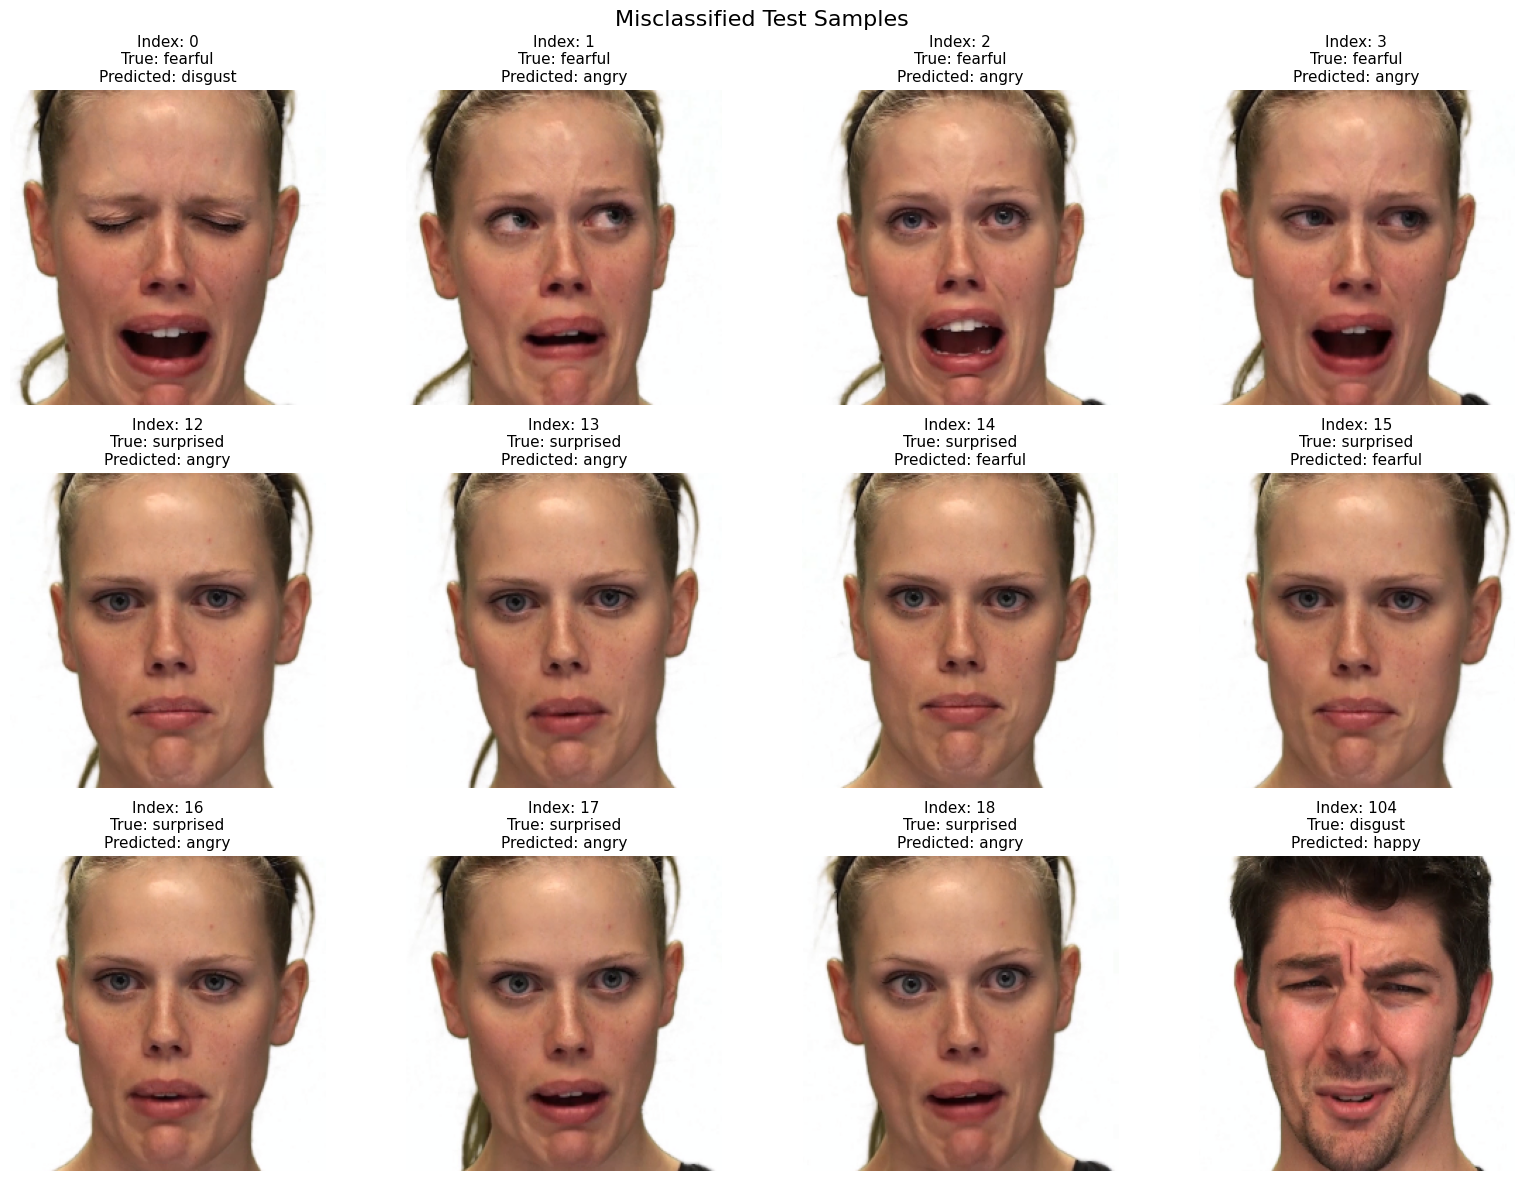

Đã hiển thị các mẫu dự đoán sai.
Đã lưu hình ảnh Error Analysis.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/error_analysis/misclassified_samples.png


In [20]:
import matplotlib.pyplot as plt
import torch

# Số lượng mẫu hiển thị
NUM_DISPLAY_SAMPLES = len(selected_error_indices)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for plot_idx, test_idx in enumerate(selected_error_indices):

    # Lấy video và label từ Test Dataset
    video_tensor, label_tensor = test_dataset[int(test_idx)]

    # Chọn frame ở giữa chuỗi 16 frame
    middle_frame = video_tensor[
        MODEL_CONFIG['sequence_length'] // 2
    ]

    # Chuyển tensor từ C,H,W về H,W,C
    frame = middle_frame.permute(1, 2, 0).numpy()

    # Khôi phục ảnh sau bước ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    frame = frame * std + mean
    frame = np.clip(frame, 0, 1)

    true_label = CLASS_NAMES[
        all_labels_array[test_idx]
    ]

    predicted_label = CLASS_NAMES[
        all_predictions_array[test_idx]
    ]

    # Hiển thị frame
    axes[plot_idx].imshow(frame)

    axes[plot_idx].set_title(
        f"Index: {test_idx}\n"
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}",
        fontsize=11
    )

    axes[plot_idx].axis('off')

plt.suptitle(
    'Misclassified Test Samples',
    fontsize=16
)

plt.tight_layout()

# Lưu hình ảnh Error Analysis
misclassified_samples_path = os.path.join(
    ERROR_ANALYSIS_DIR,
    'misclassified_samples.png'
)

plt.savefig(
    misclassified_samples_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Đã hiển thị các mẫu dự đoán sai.")
print("Đã lưu hình ảnh Error Analysis.")
print("Đường dẫn:", misclassified_samples_path)

#Cell 21 — Tổng hợp và Lưu Báo cáo Error Analysis

In [21]:
# Lấy 5 cặp lỗi phổ biến nhất
top_errors = misclassification_df.head(5)

# Tạo nội dung báo cáo
error_analysis_lines = []

error_analysis_lines.append(
    "ERROR ANALYSIS - TEST SET\n"
)

error_analysis_lines.append(
    "=" * 70 + "\n\n"
)

error_analysis_lines.append(
    f"Test Accuracy: {test_accuracy * 100:.2f}%\n"
)

error_analysis_lines.append(
    f"Total Test Samples: {len(all_labels_array)}\n"
)

error_analysis_lines.append(
    f"Misclassified Samples: {len(misclassified_indices)}\n"
)

error_analysis_lines.append(
    f"Error Rate: "
    f"{len(misclassified_indices) / len(all_labels_array) * 100:.2f}%\n\n"
)

error_analysis_lines.append(
    "TOP 5 MISCLASSIFICATION PAIRS\n"
)

error_analysis_lines.append(
    "-" * 70 + "\n"
)

for _, row in top_errors.iterrows():
    error_analysis_lines.append(
        f"{row['True Emotion']} -> "
        f"{row['Predicted Emotion']}: "
        f"{row['Number of Errors']} errors\n"
    )

error_analysis_lines.append("\n")

error_analysis_lines.append(
    "GENERAL ERROR ANALYSIS\n"
)

error_analysis_lines.append(
    "-" * 70 + "\n"
)

error_analysis_lines.append(
    "1. The model frequently predicts several emotions as 'angry'.\n"
)

error_analysis_lines.append(
    "2. The most frequent confusion is surprised -> angry, "
    "with 23 misclassified samples.\n"
)

error_analysis_lines.append(
    "3. Fearful -> angry and calm -> angry are also frequent "
    "misclassification patterns.\n"
)

error_analysis_lines.append(
    "4. Disgust -> sad is another common confusion pattern.\n"
)

error_analysis_lines.append(
    "5. Possible causes include similarities between facial expressions, "
    "face detection quality, facial angle, frame quality, and "
    "temporal information extracted from the video.\n"
)

error_analysis_lines.append(
    "\nVISUAL INSPECTION\n"
)

error_analysis_lines.append(
    "-" * 70 + "\n"
)

error_analysis_lines.append(
    "Representative misclassified samples were selected and visualized "
    "in misclassified_samples.png.\n"
)

# Đường dẫn file báo cáo
error_analysis_summary_path = os.path.join(
    ERROR_ANALYSIS_DIR,
    'error_analysis_summary.txt'
)

# Lưu báo cáo
with open(
    error_analysis_summary_path,
    'w',
    encoding='utf-8'
) as f:
    f.writelines(error_analysis_lines)

print("Đã tạo báo cáo Error Analysis.")
print("Đường dẫn:", error_analysis_summary_path)

print("\nCác file trong Error Analysis:")
print("- selected_misclassified_samples.csv")
print("- misclassified_samples.png")
print("- error_analysis_summary.txt")

Đã tạo báo cáo Error Analysis.
Đường dẫn: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/error_analysis/error_analysis_summary.txt

Các file trong Error Analysis:
- selected_misclassified_samples.csv
- misclassified_samples.png
- error_analysis_summary.txt


#Cell 22 — Xây dựng mô hình Baseline CNN + Global Average Pooling

In [22]:
# Không sử dụng LSTM hoặc GRU

import torch
import torch.nn as nn
from torchvision import models

class BaselineCNNGAP(nn.Module):
    """
    Baseline:
    ResNet18 pretrained
        ↓
    Feature extraction từng frame
        ↓
    Temporal Average Pooling
        ↓
    Fully Connected
        ↓
    8 emotions

    Không sử dụng LSTM/GRU.
    """

    def __init__(self, num_classes=8, dropout=0.5):
        super(BaselineCNNGAP, self).__init__()

        # Sử dụng cùng pretrained ResNet18 như model chính
        resnet = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        feature_dim = resnet.fc.in_features

        # Bỏ classification layer của ResNet18
        resnet.fc = nn.Identity()

        self.backbone = resnet

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        batch_size, seq_len, C, H, W = x.shape

        # Gộp batch và sequence để đưa qua CNN
        x = x.view(
            batch_size * seq_len,
            C,
            H,
            W
        )

        # Feature extraction
        features = self.backbone(x)

        # Khôi phục sequence
        features = features.view(
            batch_size,
            seq_len,
            -1
        )

        # Temporal Average Pooling
        video_feature = torch.mean(
            features,
            dim=1
        )

        # Classification
        logits = self.classifier(video_feature)

        return logits


baseline_model = BaselineCNNGAP(
    num_classes=MODEL_CONFIG['num_classes'],
    dropout=MODEL_CONFIG['dropout']
)

baseline_model = baseline_model.to(device)

print("Đã khởi tạo Baseline CNN + Global Average Pooling.")
print("=" * 60)
print("Backbone: ResNet18 Pretrained")
print("Temporal Modeling: Mean Pooling")
print("RNN: Không sử dụng LSTM/GRU")
print("Classes:", MODEL_CONFIG['num_classes'])
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


Đã khởi tạo Baseline CNN + Global Average Pooling.
Backbone: ResNet18 Pretrained
Temporal Modeling: Mean Pooling
RNN: Không sử dụng LSTM/GRU
Classes: 8
Device: cuda


#Cell 23 — Xây dựng Train và Validation Dataset cho Baseline

In [23]:
class BaselineDataset(Dataset):
    """
    Dataset dùng cho Baseline CNN.
    Dữ liệu được đọc theo từng batch .npz để hạn chế sử dụng RAM.
    """

    def __init__(self, batch_files, transform=None):
        self.batch_files = batch_files
        self.transform = transform

        # Lưu số lượng mẫu của từng batch
        self.batch_sizes = []

        for path in batch_files:
            with np.load(path) as data:
                self.batch_sizes.append(len(data['y']))

        # Tạo ánh xạ
        self.index_map = []

        for batch_idx, size in enumerate(self.batch_sizes):
            for local_idx in range(size):
                self.index_map.append(
                    (batch_idx, local_idx)
                )

        # Cache một batch tại một thời điểm
        self.cached_batch_idx = None
        self.cached_X = None
        self.cached_y = None

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):

        batch_idx, local_idx = self.index_map[idx]

        # Chỉ load batch mới khi cần
        if batch_idx != self.cached_batch_idx:

            with np.load(self.batch_files[batch_idx]) as data:
                self.cached_X = data['X'].copy()
                self.cached_y = data['y'].copy()

            self.cached_batch_idx = batch_idx

        video_seq = self.cached_X[local_idx]
        label = self.cached_y[local_idx]

        frames = []

        # Tiền xử lý từng frame
        for frame in video_seq:

            frame_tensor = self.transform(frame)

            frames.append(frame_tensor)

        # [Sequence, Channel, Height, Width]
        video_tensor = torch.stack(
            frames,
            dim=0
        )

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return video_tensor, label_tensor


# Transform giống với model chính
baseline_train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

baseline_val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Tạo Dataset
baseline_train_dataset = BaselineDataset(
    train_batch_files,
    transform=baseline_train_transform
)

baseline_val_dataset = BaselineDataset(
    val_batch_files,
    transform=baseline_val_transform
)


# Tạo DataLoader
baseline_train_loader = DataLoader(
    baseline_train_dataset,
    batch_size=MODEL_CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

baseline_val_loader = DataLoader(
    baseline_val_dataset,
    batch_size=MODEL_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("Đã tạo Baseline Train/Validation Dataset.")

print("\nThông tin Dataset:")
print(
    "Train samples:",
    len(baseline_train_dataset)
)

print(
    "Validation samples:",
    len(baseline_val_dataset)
)

print(
    "Train batches:",
    len(baseline_train_loader)
)

print(
    "Validation batches:",
    len(baseline_val_loader)
)

Đã tạo Baseline Train/Validation Dataset.

Thông tin Dataset:
Train samples: 2000
Validation samples: 380
Train batches: 125
Validation batches: 24


#Cell 24 — Thiết lập Loss Function, Optimizer và Tham số Huấn luyện Baseline

In [24]:
import torch.optim as optim

# Số epoch sử dụng cho Baseline
BASELINE_EPOCHS = MODEL_CONFIG['num_epochs']

# Learning rate và weight decay giống model chính
BASELINE_LEARNING_RATE = MODEL_CONFIG['learning_rate']
BASELINE_WEIGHT_DECAY = MODEL_CONFIG['weight_decay']

# Loss function
baseline_criterion = nn.CrossEntropyLoss()

# Optimizer
baseline_optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
    weight_decay=BASELINE_WEIGHT_DECAY
)

print("Đã thiết lập Baseline Training Configuration.")
print("=" * 60)

print("Model: ResNet18 + Global Average Pooling")
print("RNN: Không sử dụng LSTM/GRU")
print("Loss: CrossEntropyLoss")
print("Optimizer: AdamW")
print("Learning Rate:", BASELINE_LEARNING_RATE)
print("Weight Decay:", BASELINE_WEIGHT_DECAY)
print("Batch Size:", MODEL_CONFIG['batch_size'])
print("Number of Epochs:", BASELINE_EPOCHS)

Đã thiết lập Baseline Training Configuration.
Model: ResNet18 + Global Average Pooling
RNN: Không sử dụng LSTM/GRU
Loss: CrossEntropyLoss
Optimizer: AdamW
Learning Rate: 0.0001
Weight Decay: 0.0001
Batch Size: 16
Number of Epochs: 30


#Cell 25 - Huấn luyện Baseline CNN với Temporal Average Pooling

In [25]:
# Cell 25 — Baseline nhanh bằng Precomputed CNN Features (đã tối ưu tốc độ)

import time
import json
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

print("BẮT ĐẦU BASELINE NHANH")
print("=" * 70)

# ============================================================
# 1. Đóng băng ResNet18
# ============================================================

baseline_model.backbone.eval()

for param in baseline_model.backbone.parameters():
    param.requires_grad = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)




extract_train_loader = DataLoader(
    baseline_train_dataset,
    batch_size=MODEL_CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

extract_val_loader = DataLoader(
    baseline_val_dataset,
    batch_size=MODEL_CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


# ============================================================
# 2. Hàm trích xuất feature (thêm autocast để tăng tốc trên GPU)
# ============================================================

def extract_features(loader, model):

    features_list = []
    labels_list = []

    model.eval()

    use_amp = device.type == "cuda"

    with torch.no_grad():

        for batch_idx, (inputs, labels) in enumerate(loader):

            inputs = inputs.to(device, non_blocking=True)

            batch_size, seq_len, C, H, W = inputs.shape

            # Gộp video + frame
            x = inputs.view(
                batch_size * seq_len,
                C,
                H,
                W
            )

            # ResNet18 feature extraction (mixed precision nếu có GPU)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                features = model.backbone(x)

            # Khôi phục sequence
            features = features.view(
                batch_size,
                seq_len,
                -1
            )

            # Temporal Average Pooling
            video_features = torch.mean(
                features,
                dim=1
            )

            features_list.append(
                video_features.float().cpu()
            )

            labels_list.append(
                labels.cpu()
            )

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"  Batch {batch_idx + 1}/{len(loader)}"
                )

    features = torch.cat(
        features_list,
        dim=0
    )

    labels = torch.cat(
        labels_list,
        dim=0
    )

    return features, labels


# ============================================================
# 3. Extract features (có cache ra đĩa để lần sau không phải chạy lại)
# ============================================================

features_cache_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_features_cache.pt"
)

if os.path.exists(features_cache_path):

    print("\nĐã tìm thấy feature cache, load lại thay vì trích xuất lại...")

    cache = torch.load(features_cache_path, map_location="cpu")

    train_features = cache["train_features"]
    train_labels = cache["train_labels"]
    val_features = cache["val_features"]
    val_labels = cache["val_labels"]

    print("Train features:", train_features.shape)
    print("Validation features:", val_features.shape)

else:

    print("\n[1/3] Extracting TRAIN features...")

    start_time = time.time()

    train_features, train_labels = extract_features(
        extract_train_loader,
        baseline_model
    )

    print(
        f"Train features: {train_features.shape}"
    )

    print(
        f"Thời gian: {time.time() - start_time:.1f}s"
    )


    print("\n[2/3] Extracting VALIDATION features...")

    start_time = time.time()

    val_features, val_labels = extract_features(
        extract_val_loader,
        baseline_model
    )

    print(
        f"Validation features: {val_features.shape}"
    )

    print(
        f"Thời gian: {time.time() - start_time:.1f}s"
    )

    torch.save(
        {
            "train_features": train_features,
            "train_labels": train_labels,
            "val_features": val_features,
            "val_labels": val_labels
        },
        features_cache_path
    )

    print("Đã lưu feature cache tại:", features_cache_path)


# ============================================================
# 5. Train classifier
# ============================================================

print("\n[3/3] Training classifier...")

classifier = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 8)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

train_features = train_features.to(device)
train_labels = train_labels.to(device)

val_features = val_features.to(device)
val_labels = val_labels.to(device)

FAST_BASELINE_EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0

best_classifier_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_classifier.pth"
)


# ============================================================
# Training
# ============================================================

for epoch in range(FAST_BASELINE_EPOCHS):

    start_time = time.time()

    classifier.train()

    optimizer.zero_grad()

    outputs = classifier(train_features)

    loss = criterion(
        outputs,
        train_labels
    )

    loss.backward()

    optimizer.step()

    train_predictions = torch.argmax(
        outputs,
        dim=1
    )

    train_acc = (
        train_predictions == train_labels
    ).float().mean().item()


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    classifier.eval()

    with torch.no_grad():

        val_outputs = classifier(
            val_features
        )

        val_loss = criterion(
            val_outputs,
            val_labels
        )

        val_predictions = torch.argmax(
            val_outputs,
            dim=1
        )

        val_acc = (
            val_predictions == val_labels
        ).float().mean().item()


    history["train_loss"].append(
        loss.item()
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss.item()
    )

    history["val_acc"].append(
        val_acc
    )


    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{FAST_BASELINE_EPOCHS}] "
        f"| Train Loss: {loss.item():.4f} "
        f"| Train Acc: {train_acc*100:.2f}% "
        f"| Val Loss: {val_loss.item():.4f} "
        f"| Val Acc: {val_acc*100:.2f}% "
        f"| Time: {elapsed:.2f}s"
    )


    # --------------------------------------------------------
    # Save best classifier
    # --------------------------------------------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "model_state_dict": classifier.state_dict(),
                "val_acc": best_val_acc,
                "config": {
                    "model": "ResNet18 + Temporal Average Pooling",
                    "rnn_type": "None",
                    "feature_dim": 512,
                    "num_classes": 8,
                    "epochs": FAST_BASELINE_EPOCHS
                }
            },
            best_classifier_path
        )


# ============================================================
# Save history
# ============================================================

baseline_history_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_training_history.json"
)

with open(
    baseline_history_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )


print("\n" + "=" * 70)
print("BASELINE HOÀN TẤT")
print(
    f"Best Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)
print(
    "Classifier:",
    best_classifier_path
)
print(
    "History:",
    baseline_history_path
)


BẮT ĐẦU BASELINE NHANH
Device: cuda

Đã tìm thấy feature cache, load lại thay vì trích xuất lại...
Train features: torch.Size([2000, 512])
Validation features: torch.Size([380, 512])

[3/3] Training classifier...
Epoch [01/10] | Train Loss: 2.1051 | Train Acc: 12.10% | Val Loss: 2.0691 | Val Acc: 15.00% | Time: 0.29s
Epoch [02/10] | Train Loss: 2.0766 | Train Acc: 15.00% | Val Loss: 2.0572 | Val Acc: 15.53% | Time: 0.01s
Epoch [03/10] | Train Loss: 2.0713 | Train Acc: 15.30% | Val Loss: 2.0454 | Val Acc: 16.32% | Time: 0.00s
Epoch [04/10] | Train Loss: 2.0441 | Train Acc: 17.70% | Val Loss: 2.0373 | Val Acc: 13.95% | Time: 0.00s
Epoch [05/10] | Train Loss: 2.0365 | Train Acc: 17.75% | Val Loss: 2.0316 | Val Acc: 15.26% | Time: 0.00s
Epoch [06/10] | Train Loss: 2.0251 | Train Acc: 20.25% | Val Loss: 2.0257 | Val Acc: 25.53% | Time: 0.00s
Epoch [07/10] | Train Loss: 2.0141 | Train Acc: 22.35% | Val Loss: 2.0174 | Val Acc: 26.58% | Time: 0.00s
Epoch [08/10] | Train Loss: 2.0015 | Train Ac

#Cell 26 - Đánh giá Baseline trên Test Set

In [26]:
# Cell 26 — Đánh giá Baseline trên Test Set (đã tối ưu tốc độ)

import os
import time
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("BẮT ĐẦU ĐÁNH GIÁ BASELINE TRÊN TEST SET")
print("=" * 70)



print("\n[1/2] Extracting TEST features...")

start_time = time.time()

test_features, test_labels = extract_features(
    test_loader,
    baseline_model
)

print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)
print(f"Thời gian: {time.time() - start_time:.1f}s")


# ============================================================
# 2. Load Best Baseline Classifier
# ============================================================

print("\n[2/2] Loading best baseline classifier...")

best_classifier_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_classifier.pth"
)

baseline_checkpoint = torch.load(
    best_classifier_path,
    map_location=device
)

classifier = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 8)
).to(device)

classifier.load_state_dict(
    baseline_checkpoint["model_state_dict"]
)

classifier.eval()

print(
    f"Best Validation Accuracy: "
    f"{baseline_checkpoint['val_acc'] * 100:.2f}%"
)


# ============================================================
# 3. Dự đoán trên Test Set
# ============================================================

test_features = test_features.to(device)
test_labels = test_labels.to(device)

with torch.no_grad():

    test_outputs = classifier(
        test_features
    )

    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )


# ============================================================
# 4. Tính Metrics
# ============================================================

baseline_y_true = test_labels.cpu().numpy()
baseline_y_pred = test_predictions.cpu().numpy()

baseline_accuracy = accuracy_score(
    baseline_y_true,
    baseline_y_pred
)

baseline_precision = precision_score(
    baseline_y_true,
    baseline_y_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    baseline_y_true,
    baseline_y_pred,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_y_true,
    baseline_y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 5. In kết quả
# ============================================================

print("\n" + "=" * 70)
print("KẾT QUẢ BASELINE TRÊN TEST SET")
print("=" * 70)

print(f"Test Samples : {len(baseline_y_true)}")
print(f"Accuracy     : {baseline_accuracy * 100:.2f}%")
print(f"Precision    : {baseline_precision * 100:.2f}%")
print(f"Recall       : {baseline_recall * 100:.2f}%")
print(f"F1-Score     : {baseline_f1 * 100:.2f}%")


# ============================================================
# 6. Classification Report
# ============================================================

print("\nClassification Report:")

baseline_report = classification_report(
    baseline_y_true,
    baseline_y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(baseline_report)


# ============================================================
# 7. Lưu kết quả
# ============================================================

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

baseline_results_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_evaluation_results.csv"
)

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

baseline_report_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_classification_report.txt"
)

with open(
    baseline_report_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(baseline_report)

print("\nĐã lưu:")
print("-", baseline_results_path)
print("-", baseline_report_path)




BẮT ĐẦU ĐÁNH GIÁ BASELINE TRÊN TEST SET

[1/2] Extracting TEST features...
  Batch 10/32
  Batch 20/32
  Batch 30/32
Test features: torch.Size([500, 512])
Test labels: torch.Size([500])
Thời gian: 26.5s

[2/2] Loading best baseline classifier...
Best Validation Accuracy: 27.89%

KẾT QUẢ BASELINE TRÊN TEST SET
Test Samples : 500
Accuracy     : 36.60%
Precision    : 35.46%
Recall       : 36.60%
F1-Score     : 33.76%

Classification Report:
              precision    recall  f1-score   support

     neutral     0.0000    0.0000    0.0000        36
        calm     0.4255    0.5556    0.4819        72
       happy     0.9362    0.6111    0.7395        72
         sad     0.2250    0.3214    0.2647        56
       angry     0.2168    0.5536    0.3116        56
     fearful     0.0000    0.0000    0.0000        64
     disgust     0.4021    0.5417    0.4615        72
   surprised     0.3548    0.1528    0.2136        72

    accuracy                         0.3660       500
   macro avg    

#Cell 27 — Confusion Matrix của Baseline

TẠO CONFUSION MATRIX CHO BASELINE
Confusion Matrix:
[[ 0 22  0  8  2  0  0  4]
 [ 0 40  0  1 15  8  0  8]
 [ 0  2 44  1  8  0 17  0]
 [ 0  9  2 18 15  0  8  4]
 [ 0  2  0  8 31  0 15  0]
 [ 0  8  0 10 37  0  5  4]
 [ 0  2  1 11 19  0 39  0]
 [ 0  9  0 23 16  0 13 11]]


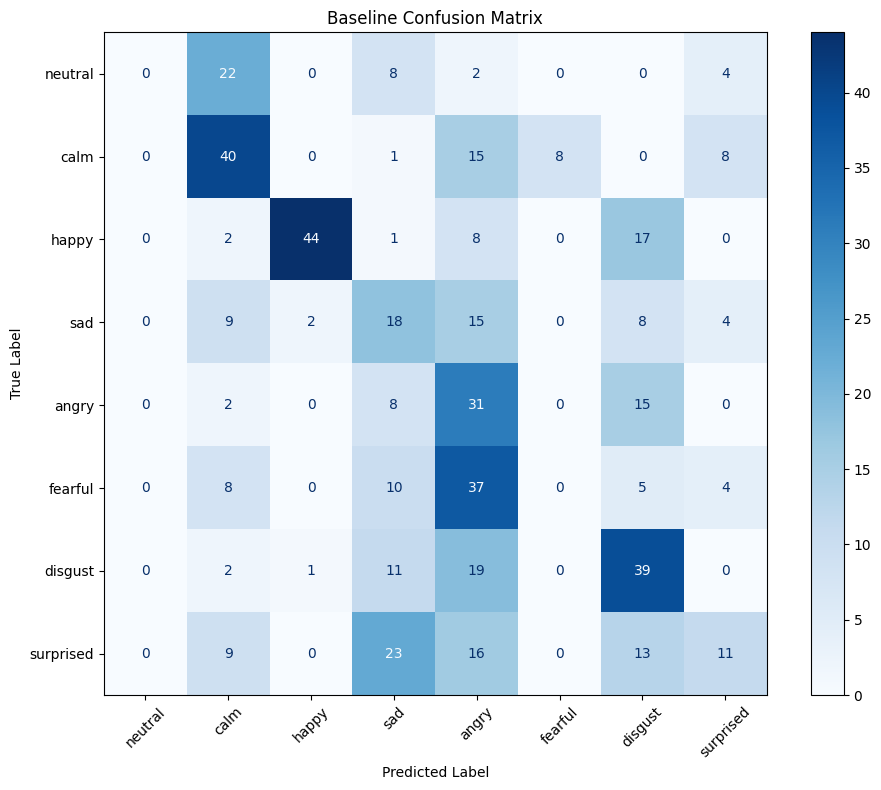


Đã lưu Confusion Matrix tại:
/content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/baseline_confusion_matrix.png


In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TẠO CONFUSION MATRIX CHO BASELINE")
print("=" * 70)

# ============================================================
# 1. Tạo Confusion Matrix
# ============================================================

cm = confusion_matrix(
    baseline_y_true,
    baseline_y_pred
)

print("Confusion Matrix:")
print(cm)


# ============================================================
# 2. Vẽ Confusion Matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Baseline Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()


# ============================================================
# 3. Lưu hình
# ============================================================

baseline_cm_path = os.path.join(
    CHECKPOINT_DIR,
    "baseline_confusion_matrix.png"
)

plt.savefig(
    baseline_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nĐã lưu Confusion Matrix tại:")
print(baseline_cm_path)



#Cell 28 — So sánh Baseline và Proposed Model

In [28]:
import os
import pandas as pd
from IPython.display import display as ipy_display

print("SO SÁNH BASELINE VÀ PROPOSED MODEL")
print("=" * 70)


# ============================================================
# 1. Kết quả Proposed Model
# ============================================================

proposed_accuracy = 0.6820
proposed_precision = 0.7779
proposed_recall = 0.6820
proposed_f1 = 0.6823


# ============================================================
# 2. Kết quả Baseline
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Baseline CNN + Temporal Average": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Proposed ResNet18 + BiLSTM": [
        proposed_accuracy,
        proposed_precision,
        proposed_recall,
        proposed_f1
    ]
})


# ============================================================
# 3. Tính chênh lệch
# ============================================================

comparison["Improvement"] = (
    comparison["Proposed ResNet18 + BiLSTM"]
    - comparison["Baseline CNN + Temporal Average"]
)


# ============================================================
# 4. Hiển thị bảng
# ============================================================

print("\nBẢNG SO SÁNH:")

ipy_display(
    comparison.style.format({
        "Baseline CNN + Temporal Average": "{:.4f}",
        "Proposed ResNet18 + BiLSTM": "{:.4f}",
        "Improvement": "{:+.4f}"
    })
)


# ============================================================
# 5. Lưu kết quả
# ============================================================

comparison_path = os.path.join(
    CHECKPOINT_DIR,
    "model_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 6. In kết quả dạng phần trăm
# ============================================================

print("\n" + "=" * 70)
print("SO SÁNH THEO PHẦN TRĂM")
print("=" * 70)

for _, row in comparison.iterrows():

    print(
        f"{row['Metric']:10s} | "
        f"Baseline: "
        f"{row['Baseline CNN + Temporal Average'] * 100:.2f}% | "
        f"Proposed: "
        f"{row['Proposed ResNet18 + BiLSTM'] * 100:.2f}% | "
        f"Chênh lệch: "
        f"{row['Improvement'] * 100:+.2f} điểm %"
    )


print("\nĐã lưu bảng so sánh tại:")
print(comparison_path)



SO SÁNH BASELINE VÀ PROPOSED MODEL

BẢNG SO SÁNH:


,Metric,Baseline CNN + Temporal Average,Proposed ResNet18 + BiLSTM,Improvement
0,Accuracy,0.3660,0.6820,+0.3160
1,Precision,0.3546,0.7779,+0.4233
2,Recall,0.3660,0.6820,+0.3160
3,F1-Score,0.3376,0.6823,+0.3447



SO SÁNH THEO PHẦN TRĂM
Accuracy   | Baseline: 36.60% | Proposed: 68.20% | Chênh lệch: +31.60 điểm %
Precision  | Baseline: 35.46% | Proposed: 77.79% | Chênh lệch: +42.33 điểm %
Recall     | Baseline: 36.60% | Proposed: 68.20% | Chênh lệch: +31.60 điểm %
F1-Score   | Baseline: 33.76% | Proposed: 68.23% | Chênh lệch: +34.47 điểm %

Đã lưu bảng so sánh tại:
/content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/model_comparison.csv


#Cell 29 — Tổng hợp kết quả thực nghiệm

In [29]:
import os
import json
import pandas as pd

print("TỔNG HỢP KẾT QUẢ THỰC NGHIỆM")
print("=" * 70)


# ============================================================
# 1. Tổng hợp thông tin Model
# ============================================================

summary = {
    "Dataset": "RAVDESS",
    "Total videos": 2880,
    "Test samples": 500,
    "Sequence length": 16,
    "Image size": "224x224",
    "Number of classes": 8,

    "Proposed Model":
        "ResNet18 + BiLSTM",

    "Baseline Model":
        "ResNet18 + Temporal Average Pooling",

    "Proposed Test Accuracy":
        proposed_accuracy,

    "Proposed Test Precision":
        proposed_precision,

    "Proposed Test Recall":
        proposed_recall,

    "Proposed Test F1":
        proposed_f1,

    "Baseline Test Accuracy":
        baseline_accuracy,

    "Baseline Test Precision":
        baseline_precision,

    "Baseline Test Recall":
        baseline_recall,

    "Baseline Test F1":
        baseline_f1,

    "Accuracy Improvement":
        proposed_accuracy - baseline_accuracy,

    "F1 Improvement":
        proposed_f1 - baseline_f1
}


# ============================================================
# 2. Hiển thị tổng hợp
# ============================================================

print("\nTHÔNG TIN THỰC NGHIỆM")
print("-" * 70)

for key, value in summary.items():

    if isinstance(value, float):
        if "Improvement" in key:
            print(
                f"{key:30s}: "
                f"{value * 100:+.2f} điểm %"
            )
        elif "Accuracy" in key or "Precision" in key \
                or "Recall" in key or "F1" in key:
            print(
                f"{key:30s}: "
                f"{value * 100:.2f}%"
            )
        else:
            print(
                f"{key:30s}: {value:.4f}"
            )
    else:
        print(
            f"{key:30s}: {value}"
        )


# ============================================================
# 3. Lưu Summary JSON
# ============================================================

summary_json_path = os.path.join(
    CHECKPOINT_DIR,
    "experiment_summary.json"
)

with open(
    summary_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 4. Tạo bảng kết quả cuối cùng
# ============================================================

final_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Baseline CNN + Temporal Average": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Proposed ResNet18 + BiLSTM": [
        proposed_accuracy,
        proposed_precision,
        proposed_recall,
        proposed_f1
    ],

    "Improvement (percentage points)": [
        proposed_accuracy - baseline_accuracy,
        proposed_precision - baseline_precision,
        proposed_recall - baseline_recall,
        proposed_f1 - baseline_f1
    ]
})


# ============================================================
# 5. Lưu bảng cuối cùng
# ============================================================

final_comparison_path = os.path.join(
    CHECKPOINT_DIR,
    "final_model_comparison.csv"
)

final_comparison.to_csv(
    final_comparison_path,
    index=False
)


print("\n" + "=" * 70)
print("FILES ĐÃ LƯU")
print("=" * 70)

print(
    "Experiment Summary:",
    summary_json_path
)

print(
    "Final Comparison:",
    final_comparison_path
)



print("\nPHẦN MODEL EVALUATION & EXPERIMENTS ĐÃ HOÀN THÀNH.")

TỔNG HỢP KẾT QUẢ THỰC NGHIỆM

THÔNG TIN THỰC NGHIỆM
----------------------------------------------------------------------
Dataset                       : RAVDESS
Total videos                  : 2880
Test samples                  : 500
Sequence length               : 16
Image size                    : 224x224
Number of classes             : 8
Proposed Model                : ResNet18 + BiLSTM
Baseline Model                : ResNet18 + Temporal Average Pooling
Proposed Test Accuracy        : 68.20%
Proposed Test Precision       : 77.79%
Proposed Test Recall          : 68.20%
Proposed Test F1              : 68.23%
Baseline Test Accuracy        : 36.60%
Baseline Test Precision       : 35.46%
Baseline Test Recall          : 36.60%
Baseline Test F1              : 33.76%
Accuracy Improvement          : +31.60 điểm %
F1 Improvement                : +34.47 điểm %

FILES ĐÃ LƯU
Experiment Summary: /content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/experiment_summary